# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.
# Question 1: First, I started by changing the 'Price' variable from object type to floats. Next discovered that there were some missing values. There are a total of 181 missing values in the 'Price' variable. I replaced the missing values with the median value of the 'Price' variable.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from requests import ConnectTimeout

df = pd.read_csv("data/airbnb_hw.csv")

print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')
print("_________________________________")

print(df['Price'].head())
print(df['Price'].dtype)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print("_________________________________")

print(df['Price'].tail())
print(df['Price'].dtype)

df.shape:
(30478, 13) 

df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 

_________________________________
0    145
1     37
2     28
3    199
4    549
Name: Price, dtype: object
object
_________________________________
30473    300.0
30474    125.0
30475     80.0
30476     35.0
30477     80.0
Name: Price, dtype: float64
float64


In [4]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df['Price_nan'] = df['Price'].isnull()

print('Total missings:\n', sum(df['Price_nan']), '\n')

Total missings:
 181 



In [5]:
impute_value = df['Price'].median()
df['Price_impute'] = df['Price'].fillna(impute_value)

print('Median used:', impute_value)

print('Missing before:', df['Price'].isnull().sum(),
      ' after:', df['Price_impute'].isnull().sum(), '\n')

print(df.loc[df['Price_nan'], ['Price', 'Price_impute']].head(15))

Median used: 125.0
Missing before: 181  after: 0 

      Price  Price_impute
101     NaN         125.0
263     NaN         125.0
764     NaN         125.0
1272    NaN         125.0
1275    NaN         125.0
1476    NaN         125.0
1846    NaN         125.0
1973    NaN         125.0
1977    NaN         125.0
2095    NaN         125.0
2149    NaN         125.0
2337    NaN         125.0
2405    NaN         125.0
2441    NaN         125.0
2716    NaN         125.0


In [7]:
df2 = pd.read_csv("data/mn_police_use_of_force.csv")
print(df2.shape, '\n')
print("_________________________")
print(df2.dtypes, '\n')

(12925, 13) 

_________________________
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 



In [8]:
print(df2['subject_injury'].tail())
print(df2['subject_injury'].dtype)

12920    NaN
12921    NaN
12922    NaN
12923    NaN
12924    NaN
Name: subject_injury, dtype: object
object


In [9]:
print(df2['subject_injury'].value_counts(dropna=False))

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64


In [10]:
df2['subject_injury'].isnull().sum()

9848

In [11]:
len(df2['subject_injury'])

12925

In [12]:
missing_count = df2['subject_injury'].isnull().sum()
total_count = len(df2['subject_injury'])

print('The percentage of missing values in the subject_injury variable is:', missing_count / total_count * 100, '%')

The percentage of missing values in the subject_injury variable is: 76.19342359767892 %


In [13]:
df2['subject_injury_clean'] = df2['subject_injury'].fillna('Missing')
print(df2['subject_injury_clean'].value_counts())

subject_injury_clean
Missing    9848
Yes        1631
No         1446
Name: count, dtype: int64


In [14]:
print(df2['force_type'].value_counts(dropna=False))

force_type
Bodily Force                   9430
Chemical Irritant              1593
Taser                          1307
Maximal Restraint Technique     170
Improvised Weapon               148
Gun Point Display               104
Less Lethal                      87
Police K9 Bite                   77
Baton                             4
Less Lethal Projectile            3
Firearm                           2
Name: count, dtype: int64


In [15]:
pd.crosstab(df2['force_type'], df2['subject_injury_clean'])

subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


In [16]:
missing_bodily = 7051
total_bodily = 9430

percentage = missing_bodily / total_bodily * 100

print(round(percentage, 2), '%')

missing_chemical = 1421
total_chemical = 1593

percentage = missing_chemical / total_chemical * 100

print(round(percentage, 2), '%')

74.77 %
89.2 %


In [40]:
# Your Phase 1 solution to the problem goes here
#Chicago_Crime_data
#What proportion of the values are missing?
#76.19% of the values are missing.
#Is this a concern?
#Yes, this is a concern because it indicates that the data is not being properlly recorded for most of the cases. This could potentially lead to biased conclusions being draw from the data.
#After crossing subject_injury and force_type, I discovered that most missing values came from bodyily force and chemical irritant. The police K9 bites causes the highest injury rate, which intuitily make sense. The Chemical irritant has the highest missing rate.

#Q2
#Shark Attack Data
#The range of values is all the way from 0 to 2026. After dropping all the 0 year values, the range changed to from 5 to 2026. The number of attacks shows an increasing trend overtime starting from 1940. But the attacks has shown a decreasing trend from around 2010. Around 87% of the victims are male. The proportion of unprovoked attacks is: 73.9%.

In [38]:
df3=pd.read_excel("data/GSAF5.xls")
print(df3.shape)
print('________________________')
print(df3.head())

(7117, 23)
________________________
           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age  ...                    Species   \
0   Unknown

In [39]:
print(df3.isnull().sum())

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                318
href formula       323
href               321
Case Number        319
Case Number.1      320
original order     318
Unnamed: 21       7116
Unnamed: 22       7115
dtype: int64


In [34]:
df3 = df3.drop(columns=['Unnamed: 21', 'Unnamed: 22'])
print(df3['Year'].value_counts(dropna=False))

Year
2015.0    143
2017.0    141
2016.0    133
0.0       129
2011.0    128
         ... 
1784.0      1
1783.0      1
1780.0      1
1779.0      1
1800.0      1
Name: count, Length: 262, dtype: int64


In [35]:
print(df3['Year'].min())
print(df3['Year'].max())

0.0
2026.0


In [36]:
import numpy as np
df3['Year'] = df3['Year'].replace(0, np.nan)
print(df3['Year'].min())
print(df3['Year'].max())

5.0
2026.0


In [46]:
df3_after1940 = df3[df3['Year'] >= 1940]
print(df3_after1940['Year'].min())
print(df3_after1940['Year'].max())


1940.0
2026.0


<Axes: xlabel='Year'>

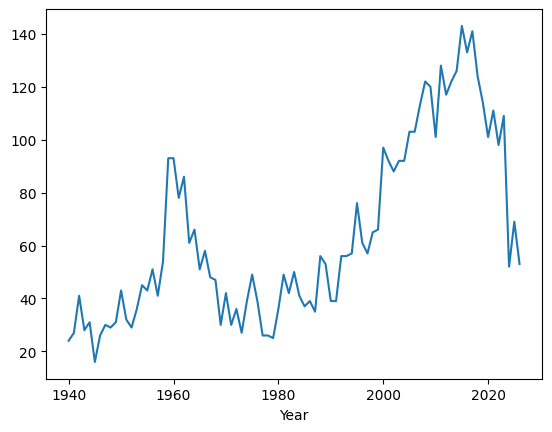

In [48]:
attacks_per_year = df3_after1940['Year'].value_counts().sort_index()
attacks_per_year.plot()

In [49]:
print(df3['Age'].value_counts(dropna=False))

Age
NaN         2994
16            92
19            90
17            89
17            87
            ... 
84             1
M              1
36 & 26        1
77             1
13 or 14       1
Name: count, Length: 253, dtype: int64


In [50]:
df3['Age_clean'] = pd.to_numeric(df3['Age'], errors='coerce')
print(df3['Age_clean'].describe())

count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age_clean, dtype: float64


<Axes: >

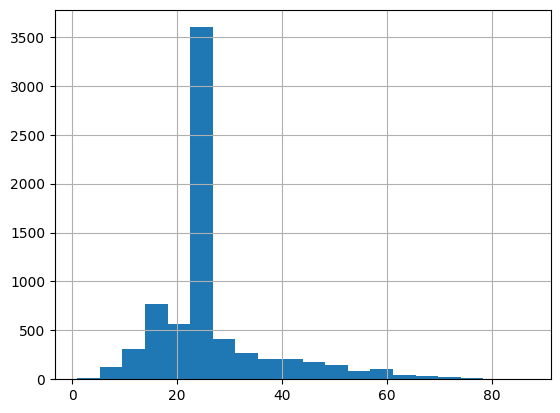

In [53]:
age_median = df3['Age_clean'].median()
df3['Age_clean'] = df3['Age_clean'].fillna(age_median)

df3['Age_clean'].hist(bins=20)

In [54]:
print(df3['Sex'].value_counts(dropna=False))

Sex
M        5704
F         816
NaN       578
M           7
?           2
F           2
N           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64


In [55]:
df3['Sex_clean'] = df3['Sex'].str.strip().str.upper()
print(df3['Sex_clean'].value_counts(dropna=False))

Sex_clean
M        5713
F         818
NaN       578
?           2
N           2
M F         1
LLI         1
M X 2       1
.           1
Name: count, dtype: int64


In [59]:
male = (df3['Sex_clean'] == 'M').sum()
total_sex = ((df3['Sex_clean'] == 'M') | (df3['Sex_clean'] == 'F')).sum()
male_proportion = male / total_sex
print('the total proportion of male victims is:', male_proportion * 100, '%')

the total proportion of male victims is: 87.47511866482928 %


In [60]:
print(df3['Type'].value_counts(dropna=False))

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
NaN                      18
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64


In [62]:
df3['Type_clean'] = df3['Type'].str.strip().str.lower()

print(df3['Type_clean'].value_counts(dropna=False))

Type_clean
unprovoked             5263
provoked                649
invalid                 552
watercraft              355
sea disaster            242
questionable             27
NaN                      18
boat                      7
?                         1
unconfirmed               1
unverified                1
under investigation       1
Name: count, dtype: int64


In [64]:
df3.loc[~df3['Type_clean'].isin(['provoked', 'unprovoked']), 'Type_clean'] = 'unknown'
print(df3['Type_clean'].value_counts())

Type_clean
unprovoked    5263
unknown       1205
provoked       649
Name: count, dtype: int64


In [67]:
un = (df3['Type_clean'] == 'unprovoked').sum()
total_attacks = len(df3)
un_proportion = un / total_attacks
print('The proportion of unprovoked attacks is:', un_proportion * 100, '%')

The proportion of unprovoked attacks is: 73.94969790642124 %


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]